## 过拟合和欠拟合
通过多项式拟合来探索这些

In [26]:
import math
import numpy as np 
import torch
import trainch3
from torch import nn 
from d2l import torch as d2l

#### 生成数据集
给定x，我们讲使用以下三阶多项式来生成训练和测试数据的标签:$$y=5+1.2x-3.4\frac{x^2}{2!}+5.6\frac{x^3}{3!}+\epsilon\mathrm{~where~}\epsilon\sim\mathcal{N}(0,0.1^2).$$ 噪声项$\epsilon$服从均值为0且标准差为0.1的正态分布。 在优化的过程中，我们通常希望避免非常大的梯度值或损失值。 这就是我们将特征从$x^{i}$调整为$\frac{x^{i}}{i!}$的原因， 这样可以避免很大的i带来的特别大的指数值。 我们将为训练集和测试集各生成100个样本。

In [27]:
max_degree = 20 # 多项式的最大阶数
n_train,n_test = 100,100 # 训练和测试数据集大小
true_w = np.zeros(max_degree) # 分配大量的空间
true_w[0:4] = np.array([5,1.2,-3.4,5.6])

features = np.random.normal(size=(n_train+n_test,1)) # 创建一个连续的特征向量集合，每个样本都只有一个维度的特征值，并且这些特征值都是独立同分布的正态随机变量
np.random.shuffle(features)
poly_features = np.power(features,np.arange(max_degree).reshape(1,-1)) # 会生成一个新的矩阵，其中原始特征值被提升到从0到 max_degree-1 的所有幂次。
for i in range(max_degree):
    poly_features[:,i] /= math.gamma(i+1) # 为每一项多项式特征赋予一个特定的权重或标准化尺度。
# labels维度:(n_train+n_test)
labels = np.dot(poly_features,true_w)
labels += np.random.normal(scale=0.1,size=labels.shape) # 模拟噪声


In [28]:
# Numpy ndarray转换成tensor
true_w,features,poly_features,labels = [torch.tensor(x,dtype=torch.float32)for x in [true_w,features,poly_features,labels]]

features[:2],poly_features[:2,:],labels[:2]

(tensor([[-0.5580],
         [-0.5328]]),
 tensor([[ 1.0000e+00, -5.5796e-01,  1.5566e-01, -2.8950e-02,  4.0382e-03,
          -4.5063e-04,  4.1905e-05, -3.3402e-06,  2.3296e-07, -1.4442e-08,
           8.0581e-10, -4.0873e-11,  1.9005e-12, -8.1567e-14,  3.2508e-15,
          -1.2092e-16,  4.2167e-18, -1.3840e-19,  4.2900e-21, -1.2598e-22],
         [ 1.0000e+00, -5.3276e-01,  1.4192e-01, -2.5203e-02,  3.3568e-03,
          -3.5768e-04,  3.1760e-05, -2.4172e-06,  1.6097e-07, -9.5291e-09,
           5.0767e-10, -2.4588e-11,  1.0916e-12, -4.4738e-14,  1.7025e-15,
          -6.0468e-17,  2.0134e-18, -6.3099e-20,  1.8676e-21, -5.2368e-23]]),
 tensor([3.7932, 3.8090]))

#### 对模型进行训练和测试

In [29]:
def evaluate_loss(net,data_iter,loss):
    """评估给定数据集上模型的损失"""
    metric = d2l.Accumulator(2) # 损失的总和，样本数量
    for x,y in data_iter:
        out = net(x)
        y = y.reshape(out.shape)
        l = loss(out,y)
        metric.add(l.sum(),l.numel())
    return metric[0]/metric[1] #返回平均损失

In [30]:
# 训练函数
def train(train_features,test_features,train_labels,test_labels,num_epochs=400):
    loss = nn.MSELoss(reduction='none') # 均方误差
    input_shape = train_features.shape[-1] 
    # 在多项式中已经实现了偏置，故这里不设置
    net = nn.Sequential(nn.Linear(input_shape,1,bias=False)) # 输入数据通过一个没有偏置项的全连接层，最终得到一个单一数值的输出
    batch_size = min(10,train_labels.shape[0]) # 保证训练样本不超过10个
    train_iter = d2l.load_array((train_features,train_labels.reshape(-1,1)),batch_size)
    test_iter = d2l.load_array((test_features,test_labels.reshape(-1,1)),batch_size,is_train=False)
    trainer = torch.optim.SGD(net.parameters(),lr=0.01)
    animator = d2l.Animator(xlabel='epoch',ylabel='loss',yscale='log',xlim=[1,num_epochs],ylim=[1e-3,1e2],legend=['train','test'])
    for epoch in range(num_epochs):
        trainch3.train_epoch_ch3(net,train_iter,loss,trainer)
        if epoch == 0 or (epoch + 1) % 20 ==0:
            animator.add(epoch+1,(evaluate_loss(net,train_iter,loss),evaluate_loss(net,test_iter,loss)))
    print('weight:',net[0].weight.data.numpy())

##### 三阶多项式拟合(正常)

weight: [[ 4.989764   1.2284578 -3.3897033  5.5760236]]


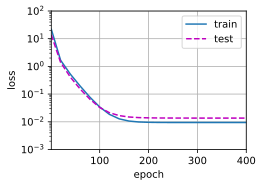

In [31]:
# 从多项式特征中选择前4个维度，即1，x,x^2,/2!,x^3/3!
train(poly_features[:n_train,:4],poly_features[n_train:,:4],labels[:n_train],labels[n_train:])

##### 线性函数拟合(欠拟合)
让我们再看看线性函数拟合，减少该模型的训练损失相对困难。 在最后一个迭代周期完成后，训练损失仍然很高。
当用来拟合非线性模式（如这里的三阶多项式函数）时，线性模型容易欠拟合。

weight: [[3.1607428 4.0541015]]


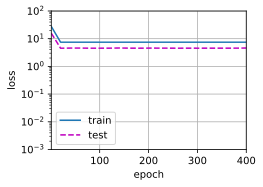

In [33]:
# 从多项式特征中选择前两个维度，即1和x
train(poly_features[:n_train,:2],poly_features[n_train:,:2],labels[:n_train],labels[n_train:])

#### 高阶多项式函数拟合(过拟合)
现在，让我们尝试使用一个阶数过高的多项式来训练模型。 在这种情况下，没有足够的数据用于学到高阶系数应该具有接近于零的值。 因此，这个过于复杂的模型会轻易受到训练数据中噪声的影响。 虽然训练损失可以有效地降低，但测试损失仍然很高。 结果表明，复杂模型对数据造成了过拟合。

weight: [[ 4.962558    1.3122845  -3.2411258   5.1326733  -0.4919824   1.3036836
   0.05866692  0.2609905  -0.0460779  -0.09504063 -0.14044364 -0.22164713
  -0.01846761 -0.15747903  0.05143991 -0.1355809   0.17121994 -0.13837364
   0.09590697  0.19311413]]


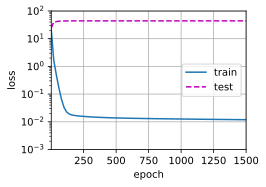

In [34]:
# 从多项式特征中选取所有维度
train(poly_features[:n_train,:],poly_features[:n_train,:],labels[:n_train],labels[n_train:],num_epochs=1500)